# EcoSort Waste Management Assistant
# Module 8 Summative Lab

## Overview

You are a data scientist at "EcoSort," a technology company that specializes in developing AI solutions for waste management. EcoSort has partnered with Metro City's waste management department to develop an intelligent waste management assistant that can help residents properly dispose of waste items so less time is spent sorting material at facilities.

This assistant needs to:

1. Identify waste materials from images uploaded by residents (CNN)
2. Classify waste items based on text descriptions provided by residents (RNN/Transformer)
3. Generate specific recycling instructions based on identified waste type and city policies (Generative Transformer with RAG)

Your task is to build this integrated system using the RealWaste dataset along with generated text data that simulates real-world waste management operations.

## Part 1: Dataset Exploration and Preparation

In this section, you will explore and prepare the datasets for your models.

### 1.1 Load and Explore the RealWaste Dataset

In [27]:
# Import necessary libraries
# - data handling
import pandas as pd
import numpy as np

from warnings import filterwarnings
filterwarnings('ignore')

# - plotting
import matplotlib.pyplot as plt
import seaborn as sns

# - text preprocessing
import nltk
import re
import string
from collections import Counter

# - NLP libraries
from nltk.tokenize import word_tokenize,sent_tokenize, RegexpTokenizer
from nltk.corpus import stopwords, wordnet
from nltk.stem import PorterStemmer,WordNetLemmatizer, SnowballStemmer
from nltk.probability import FreqDist
from nltk import pos_tag
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.util import ngrams

# -  NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('vader_lexicon')

# - sklearn libraries
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# - deep learning libraries
import torch
from transformers import AutoModelForCausalLM,AutoTokenizer
from sentence_transformers import SentenceTransformer
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Conv2D,Flatten,MaxPooling2D
from tensorflow.keras.utils import to_categorical

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
np.random.seed(42)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


###REAL WASTE DATASET

### 1.2 Explore Text Datasets

In [9]:
import os
print(os.listdir("/content"))

['.config', '.ipynb_checkpoints', 'RealWaste.zip', 'sample_data']


In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
import os
os.listdir('/content/drive/MyDrive')

['Colab Notebooks',
 'OrderedProbabilityNotes.gdoc',
 'Copy of grade-1-hygiene-and-nutrition-lesson-notes-VERSION 2.docx',
 'RealWaste']

In [21]:
os.listdir('/content/drive/MyDrive/RealWaste')

['Miscellaneous Trash',
 'Cardboard',
 'Paper',
 'Vegetation',
 'Textile Trash',
 'Metal',
 'Plastic',
 'Glass',
 'Food Organics']

DATASET STRUCTURE
Number of categories: 9
Categories:
- Cardboard
- Food Organics
- Glass
- Metal
- Miscellaneous Trash
- Paper
- Plastic
- Textile Trash
- Vegetation

DISTRIBUTION OF WASTE CATEGORIES
           Category  Number_of_Images
            Plastic               921
              Metal               790
              Paper               505
Miscellaneous Trash               495
          Cardboard               461
         Vegetation               436
              Glass               420
      Food Organics               411
      Textile Trash               326

Total number of images: 4765


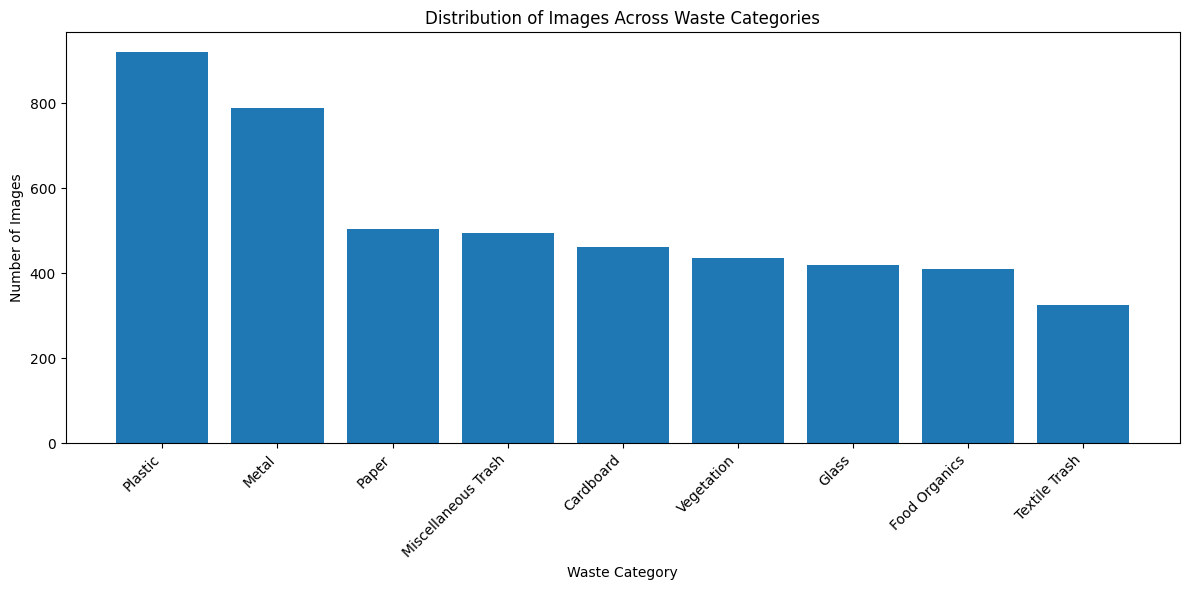


IMAGE CHARACTERISTICS

Image formats:
Format
JPEG    4765
Name: count, dtype: int64

Color modes:
Mode
RGB    4765
Name: count, dtype: int64

IMAGE RESOLUTION

Width statistics:
count    4765.0
mean      524.0
std         0.0
min       524.0
25%       524.0
50%       524.0
75%       524.0
max       524.0
Name: Width, dtype: float64

Height statistics:
count    4765.0
mean      524.0
std         0.0
min       524.0
25%       524.0
50%       524.0
75%       524.0
max       524.0
Name: Height, dtype: float64

Most common resolutions:
Width  Height
524    524       4765
dtype: int64

Number of very small images: 0

SAMPLE IMAGES - QUALITY AND BACKGROUND INSPECTION


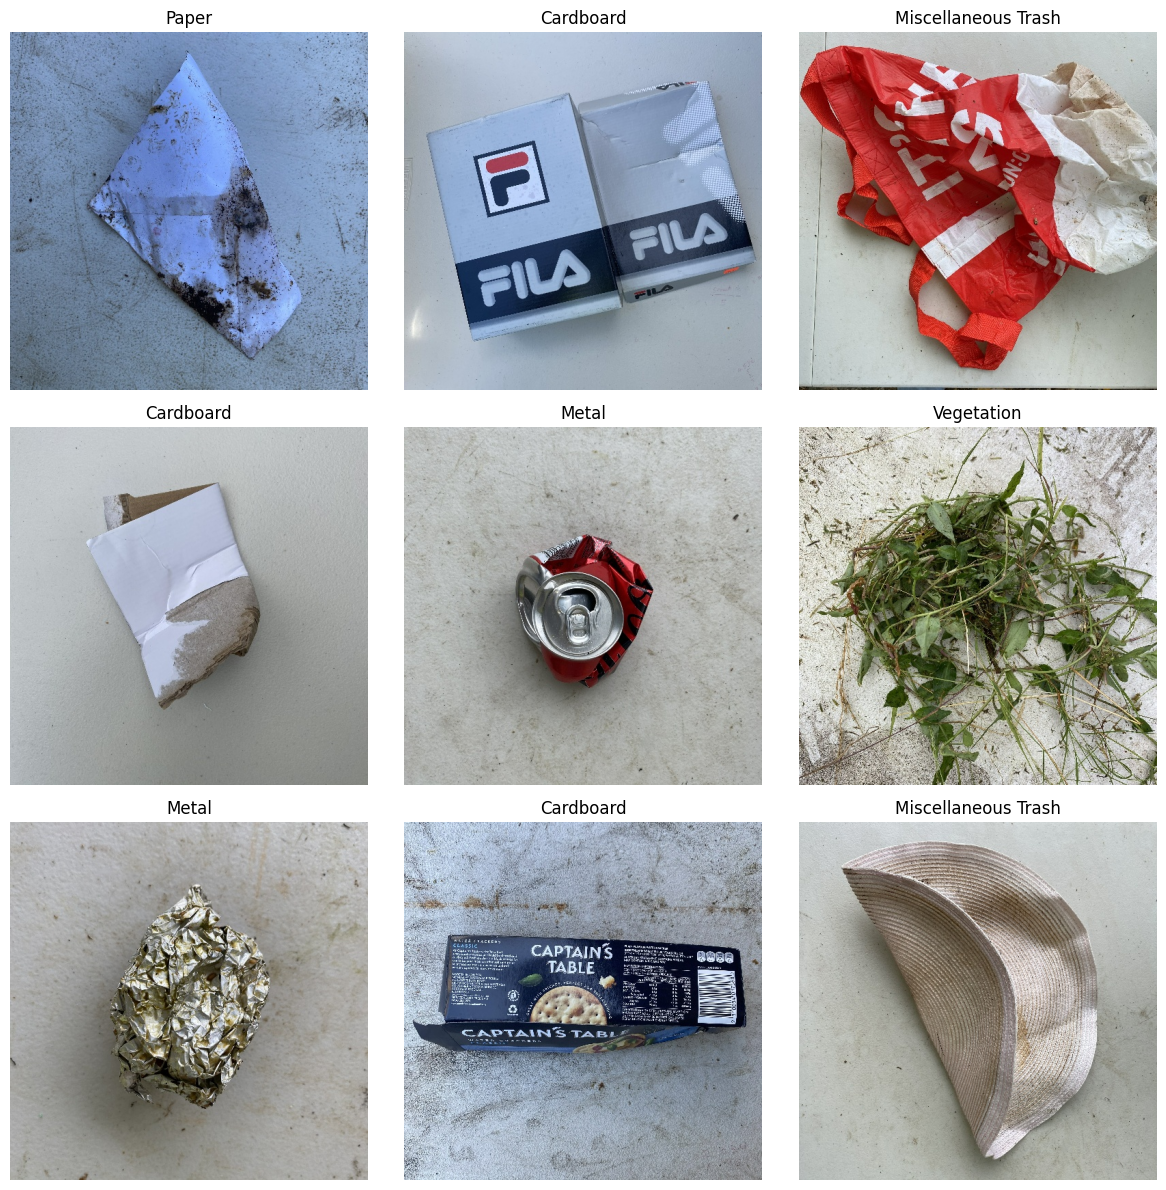

In [23]:
# TODO: Load and explore the RealWaste dataset
# - Dataset structure
# - Distribution of waste categories
# - Image characteristics (resolution, quality, background)

# Your code here
#loading of the datasets

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# 1. Dataset path
realwaste_path = '/content/drive/MyDrive/RealWaste'

# 2. Find waste categories
categories = [
    folder for folder in os.listdir(realwaste_path)
    if os.path.isdir(os.path.join(realwaste_path, folder))
]

print("=" * 50)
print("DATASET STRUCTURE")
print("=" * 50)

print("Number of categories:", len(categories))
print("Categories:")

for category in sorted(categories):
    print("-", category)


# 3. Count images in each category
category_counts = {}

for category in categories:
    category_path = os.path.join(realwaste_path, category)

    images = [
        file for file in os.listdir(category_path)
        if file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp'))
    ]

    category_counts[category] = len(images)

category_df = pd.DataFrame(
    list(category_counts.items()),
    columns=['Category', 'Number_of_Images']
)

category_df = category_df.sort_values(
    'Number_of_Images',
    ascending=False
)

print("\n" + "=" * 50)
print("DISTRIBUTION OF WASTE CATEGORIES")
print("=" * 50)

print(category_df.to_string(index=False))

print("\nTotal number of images:", category_df['Number_of_Images'].sum())


# 4. Plot category distribution
plt.figure(figsize=(12, 6))

plt.bar(
    category_df['Category'],
    category_df['Number_of_Images']
)

plt.xlabel('Waste Category')
plt.ylabel('Number of Images')
plt.title('Distribution of Images Across Waste Categories')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# 5. Collect image characteristics
image_info = []

for category in categories:

    category_path = os.path.join(realwaste_path, category)

    for file in os.listdir(category_path):

        if file.lower().endswith(
            ('.jpg', '.jpeg', '.png', '.bmp', '.webp')
        ):

            file_path = os.path.join(category_path, file)

            try:
                with Image.open(file_path) as img:

                    image_info.append({
                        'Category': category,
                        'Filename': file,
                        'Width': img.width,
                        'Height': img.height,
                        'Format': img.format,
                        'Mode': img.mode
                    })

            except Exception as e:
                print("Could not read:", file_path)


image_df = pd.DataFrame(image_info)


# 6. Image characteristics
print("\n" + "=" * 50)
print("IMAGE CHARACTERISTICS")
print("=" * 50)

print("\nImage formats:")
print(image_df['Format'].value_counts())

print("\nColor modes:")
print(image_df['Mode'].value_counts())


# 7. Resolution
print("\n" + "=" * 50)
print("IMAGE RESOLUTION")
print("=" * 50)

print("\nWidth statistics:")
print(image_df['Width'].describe())

print("\nHeight statistics:")
print(image_df['Height'].describe())

print("\nMost common resolutions:")

resolution_counts = (
    image_df
    .groupby(['Width', 'Height'])
    .size()
    .sort_values(ascending=False)
)

print(resolution_counts.head(10))


# 8. Check for very small images
small_images = image_df[
    (image_df['Width'] < 100) |
    (image_df['Height'] < 100)
]

print("\nNumber of very small images:", len(small_images))


# 9. Display sample images
print("\n" + "=" * 50)
print("SAMPLE IMAGES - QUALITY AND BACKGROUND INSPECTION")
print("=" * 50)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for ax in axes.flat:

    category = np.random.choice(categories)

    category_path = os.path.join(realwaste_path, category)

    files = [
        file for file in os.listdir(category_path)
        if file.lower().endswith(
            ('.jpg', '.jpeg', '.png', '.bmp', '.webp')
        )
    ]

    file = np.random.choice(files)
    file_path = os.path.join(category_path, file)

    img = Image.open(file_path)

    ax.imshow(img)
    ax.set_title(category)
    ax.axis('off')

plt.tight_layout()
plt.show()

##WASTE DESCRIPTION DATASET

In [ ]:
# TODO: Load and explore the waste description text data
# - Load waste_descriptions.csv
# - Analyze vocabulary and structure
# - Understand the distribution of categories

# Your code here
df_description = pd.read_csv('waste_descriptions.csv')
df_description

,description,category,disposal_instruction,common_confusion,material_composition
0,soiled silver tablecloth,Textile Trash,Look for textile recycling programs in your area.,NaN,"Fabric made from natural or synthetic fibers, ..."
1,folded glass bottle leaking,Glass,"Remove caps, lids, and corks before recycling.",NaN,"Silica-based material, may contain additives f..."
2,large Supermarket vegetable waste with food re...,Food Organics,"If no compost available, place in general waste.",NaN,Biodegradable matter derived from plant or ani...
3,intact floral carpet piece,Textile Trash,Look for textile recycling programs in your area.,NaN,"Fabric made from natural or synthetic fibers, ..."
4,empty fun-sized purple apple core,Food Organics,Keep separate from recyclable materials.,Meat and dairy products may be restricted in s...,Biodegradable matter derived from plant or ani...
...,...,...,...,...,...
4995,new red tea bags,Food Organics,Keep separate from recyclable materials.,NaN,Biodegradable matter derived from plant or ani...
4996,torn white disposable diaper sealed,Miscellaneous Trash,Hazardous items like batteries require special...,NaN,Various non-recyclable materials often with mi...
4997,broken mini apple core,Food Organics,Place in organic waste or compost bin.,Meat and dairy products may be restricted in s...,Biodegradable matter derived from plant or ani...
4998,pink glass pitcher with food residue,Glass,"Place in glass recycling bin, sorted by color ...","Window glass, drinking glasses, and ceramics s...","Silica-based material, may contain additives f..."


####Analyzing Vocabulary and Structure for Waste Description Dataset


In [ ]:
#Checking shape of the dataset
print(df_description.shape)

(5000, 5)


In [ ]:
#Checking the column names
print(df_description.columns)

Index(['description', 'category', 'disposal_instruction', 'common_confusion',
       'material_composition'],
      dtype='str')


In [ ]:
#Knowing the overall info about the dataset
print(df_description.info())

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   description           5000 non-null   str  
 1   category              5000 non-null   str  
 2   disposal_instruction  5000 non-null   str  
 3   common_confusion      2496 non-null   str  
 4   material_composition  5000 non-null   str  
dtypes: str(5)
memory usage: 1.1 MB
None


In [ ]:
#Checking for missing values
print(df_description.isnull().sum())

description                0
category                   0
disposal_instruction       0
common_confusion        2504
material_composition       0
dtype: int64


###Understanding the distribution of categories for Waste Description Dataset

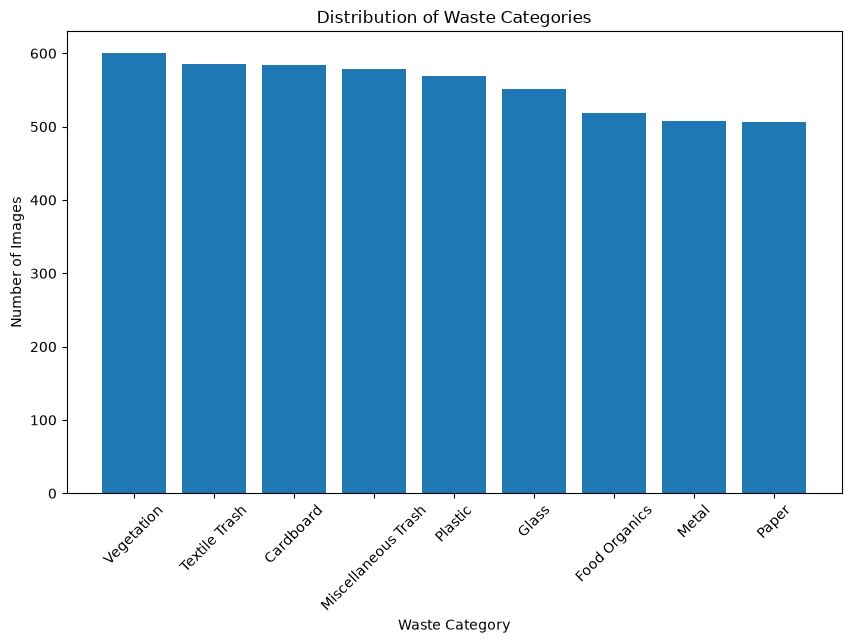

In [ ]:
# understand the distribution of  categories
category_counts = df_description['category'].value_counts()
plt.figure(figsize=(10,6))
plt.bar(category_counts.index,category_counts.values)
plt.xticks(rotation=45)
plt.xlabel('Waste Category')
plt.ylabel('Number of Images')
plt.title('Distribution of Waste Categories')
plt.show()

#WASTE POLICY DOCUMENTS DATASET

In [ ]:
# TODO: Load and explore the waste policy documents
# - Load waste_policy_documents.csv
# - Understand document organization and language

# Your code here
df_policy_documents =  pd.read_json('waste_policy_documents.json')
df_policy_documents

,policy_id,policy_type,categories_covered,effective_date,document_text,jurisdiction
0,1,Textile Trash Recycling Guidelines,[Textile Trash],2023-11-04,TEXTILE RECYCLING GUIDELINES\n\nAcceptable Ite...,Metro City
1,2,Glass Recycling Guidelines,[Glass],2023-01-24,GLASS RECYCLING GUIDELINES\n\nAcceptable Items...,Metro City
2,3,Food Organics Recycling Guidelines,[Food Organics],2023-05-08,FOOD ORGANICS RECYCLING GUIDELINES\n\nAcceptab...,Metro City
3,4,Plastic Recycling Guidelines,[Plastic],2023-04-05,PLASTIC RECYCLING GUIDELINES\n\nAcceptable Ite...,Metro City
4,5,Vegetation Recycling Guidelines,[Vegetation],2023-12-04,VEGETATION RECYCLING GUIDELINES\n\nAcceptable ...,Metro City
5,6,Cardboard Recycling Guidelines,[Cardboard],2023-11-24,CARDBOARD RECYCLING GUIDELINES\n\nAcceptable I...,Metro City
6,7,Metal Recycling Guidelines,[Metal],2023-09-03,METAL RECYCLING GUIDELINES\n\nAcceptable Items...,Metro City
7,8,Paper Recycling Guidelines,[Paper],2023-10-14,PAPER RECYCLING GUIDELINES\n\nAcceptable Items...,Metro City
8,9,Miscellaneous Trash Recycling Guidelines,[Miscellaneous Trash],2023-01-01,MISCELLANEOUS TRASH GUIDELINES\n\nItems That C...,Metro City
9,10,Municipal Waste Guidelines,"[Plastic, Miscellaneous Trash, Vegetation]",2023-10-01,MUNICIPAL WASTE GUIDELINES\n\nGENERAL REQUIREM...,Metro City


In [ ]:
#Checking the shape of the dataset
print(df_policy_documents.shape)

(14, 6)


In [ ]:
#Understanding document organization an language

print(df_policy_documents.info())

<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   policy_id           14 non-null     int64 
 1   policy_type         14 non-null     str   
 2   categories_covered  14 non-null     object
 3   effective_date      14 non-null     str   
 4   document_text       14 non-null     str   
 5   jurisdiction        14 non-null     str   
dtypes: int64(1), object(1), str(4)
memory usage: 10.8+ KB
None


In [ ]:
#checking the column names
print(df_policy_documents.columns)

Index(['policy_id', 'policy_type', 'categories_covered', 'effective_date',
       'document_text', 'jurisdiction'],
      dtype='str')


In [ ]:
#Checking the datatypes for each column
print(df_policy_documents.dtypes)

policy_id              int64
policy_type              str
categories_covered    object
effective_date           str
document_text            str
jurisdiction             str
dtype: object


In [ ]:
#Checking if there are duplicates
# df_policy_documents.duplicated().sum()

### 1.3 Create Data Pipelines

In [28]:
# Run this code to setup the images properly into train, validation, and test sets
# Set your data directory path - update this with your actual path
import pathlib
data_dir = pathlib.Path('/content/drive/MyDrive/RealWaste')

# Parameters
BATCH_SIZE = 32
IMG_HEIGHT = 224
IMG_WIDTH = 224

# Calculate the total number of classes automatically from the directory structure
num_classes = len([item for item in data_dir.glob('*') if item.is_dir()])
print(f"Number of classes: {num_classes}")

# List all class folders
class_names = sorted([item.name for item in data_dir.glob('*') if item.is_dir()])
print(f"Class names: {class_names}")

# Count all images
image_count = len(list(data_dir.glob('*/*.jpg'))) + len(list(data_dir.glob('*/*.png')))
print(f"Total images found: {image_count}")

# Create a dataset using tf.keras.utils.image_dataset_from_directory
# This will automatically split the data into training and validation sets
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,  # 20% for validation
    subset="training",
    seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical',  # For one-hot encoded labels
    shuffle=True
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,  # 20% for validation
    subset="validation",
    seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical',  # For one-hot encoded labels
    shuffle=True
)

# Create a separate test dataset by taking part of the validation set
# First, let's get the number of batches in the validation set
val_batches = tf.data.experimental.cardinality(validation_ds)
test_dataset = validation_ds.take(val_batches // 2)
validation_ds = validation_ds.skip(val_batches // 2)

print(f"Number of training batches: {tf.data.experimental.cardinality(train_ds)}")
print(f"Number of validation batches: {tf.data.experimental.cardinality(validation_ds)}")
print(f"Number of test batches: {tf.data.experimental.cardinality(test_dataset)}")

# Configure dataset for performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
validation_ds = validation_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

Number of classes: 9
Class names: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']
Total images found: 4765
Found 4765 files belonging to 9 classes.
Using 3812 files for training.
Found 4765 files belonging to 9 classes.
Using 953 files for validation.
Number of training batches: 120
Number of validation batches: 15
Number of test batches: 15


In [ ]:
# TODO: Create a text preprocessing pipeline
# - Tokenization
# - Text cleaning
# - Split data into train and test
# - Create embeddings/features

# Your code here

In [ ]:
# TODO: Prepare documents for RAG
# - Document preprocessing
# - Create embeddings for retrieval

# Your code here

## Part 2: Waste Material Classification with CNN

In this section, you will build a CNN model to classify waste materials from images.

### 2.1 Preprocess Images

In [29]:
# TODO: Implement image preprocessing
# - Apply the preprocessing pipeline created earlier

# Your code here
# 2.1 Preprocess Images

# Data augmentation for training images
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

# Apply augmentation only to the training dataset
train_ds = train_ds.map(
    lambda images, labels: (data_augmentation(images, training=True), labels),
    num_parallel_calls=tf.data.AUTOTUNE
)

# Keep validation and test images unchanged
validation_ds = validation_ds.prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.prefetch(tf.data.AUTOTUNE)

print("Image preprocessing completed.")

Image preprocessing completed.


### 2.2 Implement CNN Model with Transfer Learning

In [38]:
# TODO: Select an appropriate base model and implement transfer learning
# - Choose from MobileNet, EfficientNet, etc.
# - Add custom classification layers for the 9 waste categories
# - Configure loss function and metrics

# Your code here
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

# Number of waste categories
num_classes = 9

# Load MobileNetV2 without its original classification layer
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze the pretrained layers
base_model.trainable = False

# Build the CNN model
model = models.Sequential([
    base_model,

    layers.GlobalAveragePooling2D(),

    # Regularization
    layers.Dropout(0.3),

    # Custom classification layer for 9 waste categories
    layers.Dense(
        128,
        activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(0.001)
    ),

    layers.Dropout(0.3),

    layers.Dense(
        num_classes,
        activation='softmax'
    )
])

# Configure the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,113 (9.24 MB)

 Trainable params: 165,129 (645.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### 2.3 Train and Evaluate the Model

In [41]:
# TODO: Select an appropriate base model and implement transfer learning
# - Choose from MobileNet, EfficientNet, etc.
# - Add custom classification layers for the 9 waste categories
# - Configure loss function and metrics

# Your code here
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Callbacks to reduce overfitting and improve training
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-6
)

# Train the model
history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=20,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 228s 2s/step - accuracy: 0.5247 - loss: 1.4474 - val_accuracy: 0.3721 - val_loss: 1.8953 - learning_rate: 0.0010
Epoch 2/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 264s 2s/step - accuracy: 0.5388 - loss: 1.3993 - val_accuracy: 0.3552 - val_loss: 1.9141 - learning_rate: 0.0010
Epoch 3/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 231s 2s/step - accuracy: 0.5370 - loss: 1.3852 - val_accuracy: 0.3869 - val_loss: 1.8415 - learning_rate: 0.0010
Epoch 4/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 257s 2s/step - accuracy: 0.5632 - loss: 1.3447 - val_accuracy: 0.4101 - val_loss: 1.7744 - learning_rate: 0.0010
Epoch 5/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 232s 2s/step - accuracy: 0.5551 - loss: 1.3325 - val_accuracy: 0.4038 - val_loss: 1.7638 - learning_rate: 0.0010
Epoch 6/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 225s 2s/step - accuracy: 0.5677 - loss: 1.3092 - val_accuracy: 0.3953 - val_loss: 1.7593 - learning_rate: 0.0010
Epoch 7/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 266s 2s/step - accuracy: 0.5645 - loss: 1.

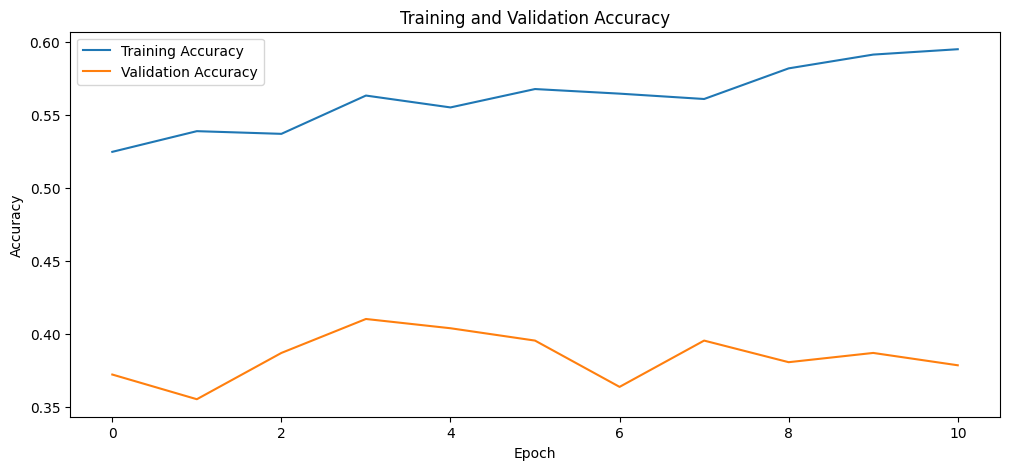

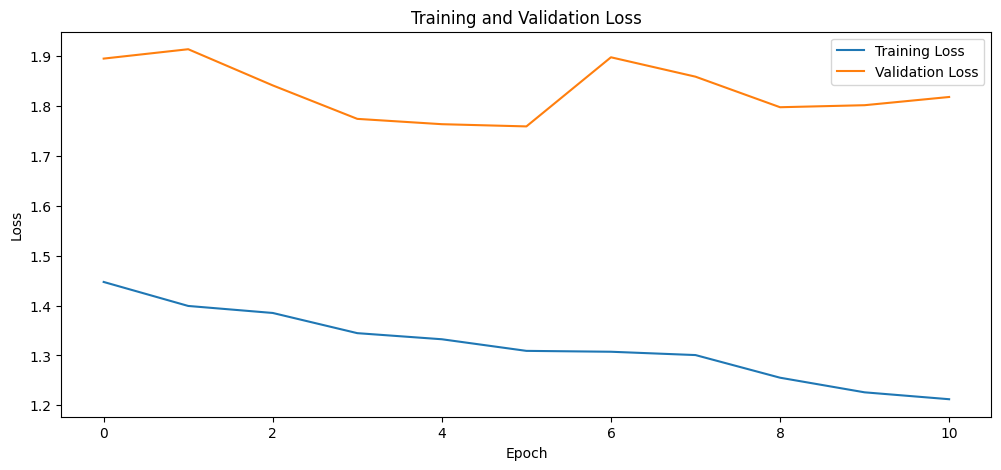

In [42]:
# Plot accuracy and loss

plt.figure(figsize=(12, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

15/15 ━━━━━━━━━━━━━━━━━━━━ 39s 3s/step - accuracy: 0.3854 - loss: 1.7742
Test Loss: 1.7741729021072388
Test Accuracy: 0.3854166567325592

Calculated Test Accuracy: 0.3854166666666667

Classification Report:
                     precision    recall  f1-score   support

          Cardboard       0.60      0.47      0.53        38
      Food Organics       0.20      0.47      0.29        38
              Glass       0.12      0.06      0.08        36
              Metal       0.66      0.38      0.48        97
Miscellaneous Trash       0.38      0.16      0.23        49
              Paper       0.67      0.52      0.59        61
            Plastic       0.28      0.44      0.35        84
      Textile Trash       0.83      0.12      0.20        43
         Vegetation       0.33      0.82      0.47        34

           accuracy                           0.39       480
          macro avg       0.45      0.38      0.36       480
       weighted avg       0.48      0.39      0.38       48

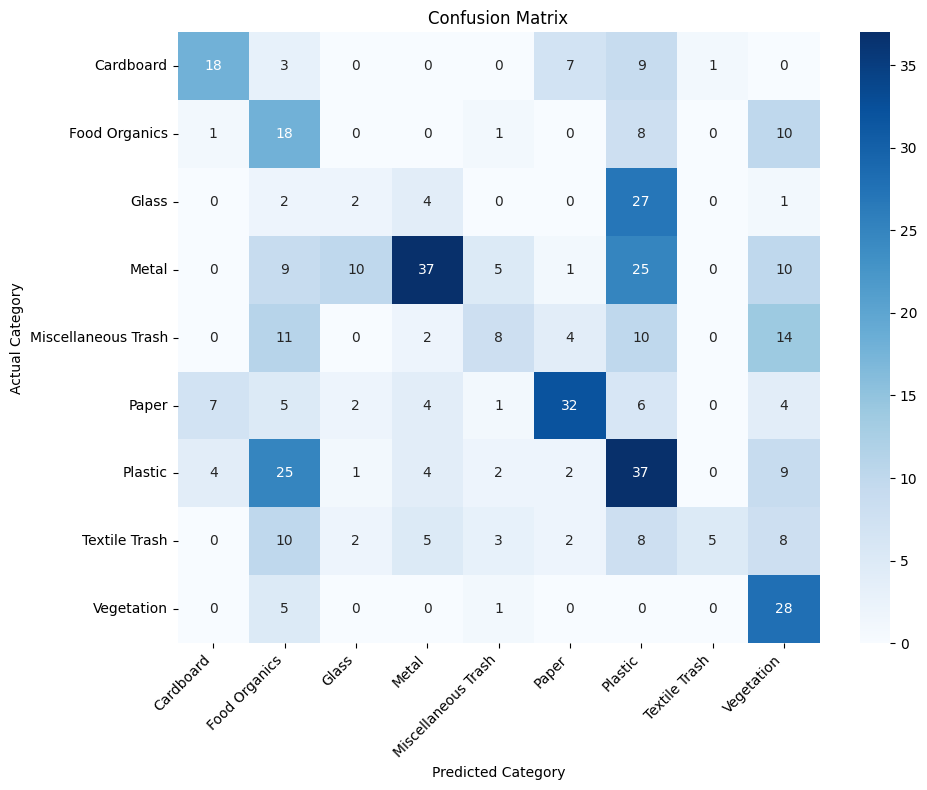

In [45]:
# TODO: Evaluate model performance
# - Calculate accuracy on test set
# - Generate confusion matrix
# - Analyze error patterns

# Your code here
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Evaluate on the test set
test_loss, test_accuracy = model.evaluate(test_dataset, verbose=1)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


# Generate predictions
y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)

    y_true.extend(np.argmax(labels.numpy(),axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)


# Accuracy
accuracy = accuracy_score(y_true, y_pred)

print("\nCalculated Test Accuracy:", accuracy)


# Classification report
print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)


# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel('Predicted Category')
plt.ylabel('Actual Category')
plt.title('Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 2.4 Fine-tune the Model

In [50]:
# TODO: Tune model parameters to improve performance
# - Adjust learning rate
# - Add regularization, dropout
# - Modify architecture if needed

# Your code here
# Unfreeze the base model
base_model.trainable = True

# Freeze the earlier layers and fine-tune only the later layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with a much smaller learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Fine-tuning callbacks
early_stopping_fine = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr_fine = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-7
)

# Fine-tune the model
fine_history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=15,
    callbacks=[
        early_stopping_fine,
        reduce_lr_fine
    ]
)

# Final evaluation
fine_test_loss, fine_test_accuracy = model.evaluate(
    test_dataset,
    verbose=1
)

print("Fine-tuned Test Accuracy:", fine_test_accuracy)

Epoch 1/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 370s 3s/step - accuracy: 0.3560 - loss: 1.9987 - val_accuracy: 0.3679 - val_loss: 2.0325 - learning_rate: 1.0000e-05
Epoch 2/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 305s 2s/step - accuracy: 0.4782 - loss: 1.5582 - val_accuracy: 0.3404 - val_loss: 2.2040 - learning_rate: 1.0000e-05
Epoch 3/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 296s 2s/step - accuracy: 0.5178 - loss: 1.4646 - val_accuracy: 0.3235 - val_loss: 2.3464 - learning_rate: 1.0000e-05
Epoch 4/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 317s 2s/step - accuracy: 0.5370 - loss: 1.4137 - val_accuracy: 0.3171 - val_loss: 2.3316 - learning_rate: 2.0000e-06
Epoch 5/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 322s 2s/step - accuracy: 0.5310 - loss: 1.4063 - val_accuracy: 0.3171 - val_loss: 2.3023 - learning_rate: 2.0000e-06
Epoch 6/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 324s 2s/step - accuracy: 0.5459 - loss: 1.3982 - val_accuracy: 0.3256 - val_loss: 2.2679 - learning_rate: 4.0000e-07
15/15 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.3354 

## Part 3: Waste Description Classification

In this section, you will build a text classification model to categorize waste based on descriptions.

### 3.1 Preprocess Text Data

In [ ]:
# TODO: Implement text preprocessing
# - Apply the text preprocessing pipeline created earlier

# Your code here

### 3.2 Implement Text Classification Model

In [ ]:
# TODO: Choose and implement a text classification model
# Option A: Traditional ML model (Naive Bayes, Random Forest, etc.)
# Option B: Fine-tune a transformer-based model (BERT, DistilBERT, etc.)

# Your code here

### 3.3 Train and Evaluate the Model

In [ ]:
# TODO: Train the text classification model
# - Use appropriate training parameters
# - Monitor training progress

# Your code here

In [ ]:
# TODO: Evaluate model performance
# - Calculate accuracy on test set
# - Generate confusion matrix
# - Analyze error patterns

# Your code here

### 3.4 Create Classification Function

In [ ]:
# TODO: Create a function that takes a text description and returns the predicted waste category

def classify_waste_description(description):
    """
    Classifies a waste description into an appropriate category.

    Args:
        description (str): Text description of waste item

    Returns:
        str: Predicted waste category
    """
    # Your code here
    pass

## Part 4: Recycling Instruction Generation with RAG

In this section, you will implement a Retrieval-Augmented Generation (RAG) system to generate recycling instructions.

### 4.1 Preprocess Documents for Retrieval

In [ ]:
# TODO: Prepare documents for retrieval
# - Process policy documents and disposal instructions
# - Create embeddings for efficient retrieval

# Your code here

### 4.2 Implement RAG-based System

In [ ]:
# TODO: Select a pre-trained language model and implement RAG
# - Choose an appropriate language model
# - Create a retrieval mechanism

# Your code here

### 4.3 Adjust and Evaluate the System

In [ ]:
# TODO: Train the RAG-based system
# - Adjust sampling methods/parameters

# Your code here

In [ ]:
# TODO: Evaluate the quality of generated instructions
# - Test with various waste categories
# - Assess relevance and accuracy

# Your code here

### 4.4 Create Instruction Generation Function

In [ ]:
# TODO: Create a function that takes a waste category and generates recycling instructions

def generate_recycling_instructions(waste_category):
    """
    Generates detailed recycling instructions for a given waste category.

    Args:
        waste_category (str): Waste category

    Returns:
        str: Detailed recycling instructions
        list: Relevant policy documents
    """
    # Your code here
    pass

## Part 5: Integrated Waste Management Assistant

In this section, you will integrate all three models into a unified waste management assistant.

### 5.1 Design Integration Architecture

In [ ]:
# TODO: Design an architecture that integrates all three models
# - Create interfaces between components
# - Handle input/output flow

# Your code here

### 5.2 Implement Integrated Assistant

In [ ]:
# TODO: Implement the integrated waste management assistant

def waste_management_assistant(input_data, input_type="image"):
    """
    Integrated waste management assistant that processes either images or text descriptions
    and returns waste classification and recycling instructions.

    Args:
        input_data: Either an image file path/array or a text description
        input_type (str): Type of input - "image" or "text"

    Returns:
        dict: Dictionary containing waste category, confidence, and recycling instructions
    """
    # Your code here
    pass

### 5.3 Evaluate the Integrated System

In [ ]:
# TODO: Evaluate the integrated system on test cases
# - Test with images from test dataset
# - Test with text descriptions from test dataset
# - Assess overall performance

# Your code here

## Submission Guidelines

1. Make sure all code cells are properly commented and annotated
2. Ensure that all functions are implemented and working correctly
3. Verify that all evaluation metrics are calculated and analyzed
4. Double-check that the integrated system works as expected
5. Submit your completed and annotated Jupyter notebook file

Remember to demonstrate your understanding of the underlying concepts and provide justification for your design decisions throughout the notebook.